## Abstract Qubo Class 

Our code is structed so that the two classes `CommunityDetection` and `AssetAllocation` are inherited from the abstract class `Qubo`. The `Qubo` abstract class represents the quadratic unconstrained binary optimization (QUBO) class of problems, and stores functions to solve them. In particular it has the following functions: 

- `build_qubo` takes in the parameters defined in the constructor of the class created the QUBO objective matrix which will be fed into the annealer, denoted in the code as `Q`. Since this function is different for community detection and asset allocation it is defined as a `@abstractmethod` in the `Qubo` class. 

- `solve` takes in the type of solver that is to be used to solve the QUBO matrix, in particular one of the following: `"EXACT"`, `"SIMULATED"`, `"HYBRID"` and `"QPU"` to represent exact diagonization (extremely slow), simulated annealing, using D Wave's hybrid solver and using D Wave's quantum annealer respectivly. 

- `decode_solution` this function takes the output of the solver and decodes it depending on the scheme used by the solving algorithm, for instance for asset allocation we decode it using one hot, community detection uses a seperate method. Since this function is different for community detection and asset allocation it is defined as a `@abstractmethod` in the `Qubo` class. 

- `run` is a function that simply runs all of the steps above, it first takes the inputs of the class and with `build_qubo` creates the QUBO objective function, then it solves it with `solve` using the predefined method then finally it decodes the solution using `decode_solution`, and returns the output. This is the only function that the user will call from any of the classes.

Recall that the community detection class takes in the adjacency matrix (`adjacency_matrix`) that is to be used to create the graph and the number of communities (`number_communities`) to create its QUBO objective function (adjacency is used to create the modularity matrix), so these are the only two parameters `CommunityDetection` takes in (alongside some predefined constants in the QUBO objective function). Asset allocation takes in the annulized returns (`returns`) and the covariance matrix `covariance` of the assets the algorithm is to run on to create its QUBO objective function. 

In [1]:
import sys
sys.path.append("..")

from src.modules import *

## Community Asset Allocation Algorithm

Our algorithm combines both community detection, we first start by getting a predefined list of assets, and getting their daily returns. Note that `daily_returns` is the returns for just one work day, in order to extrapolate to an entire year or annulize we multiply by `252`. 

In [2]:
with open("../src/assets.txt", "r") as file:
    assets = [ticker for line in file if (ticker := line.split("#")[0].split("-")[0].split(" ")[0].strip())]
    print(assets)

['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'V', 'CAT', 'GE', 'UNP', 'HON', 'NEE', 'TJX', 'BKNG', 'CMG', 'MAR', 'BLK', 'AXP']


In [3]:
daily_returns = closing_prices(assets=assets)
returns = daily_returns * 252

[*********************100%***********************]  20 of 20 completed


With these returns we can calculate the covarience matrix, which we can use to create the adjacency graph. Note that we create the graph object using `networkx`. 

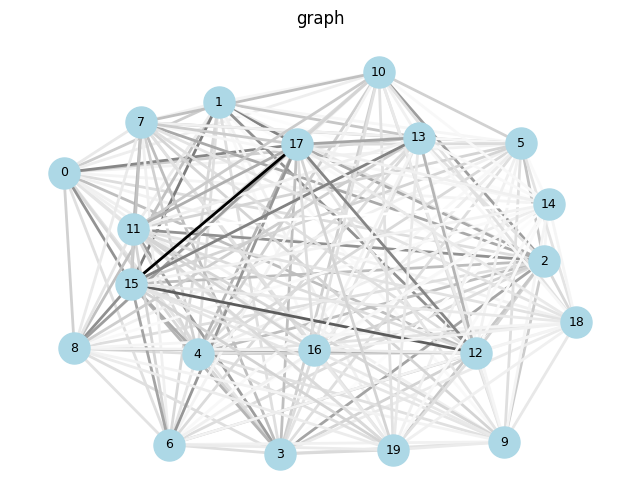

In [4]:
covariance_matrix = get_covariance(daily_returns=daily_returns)
graph = nx.from_numpy_array(covariance_matrix.to_numpy())
draw_graph(graph=graph)

Now that we have the graph we can now create an instance of `CommunityDetection` to solve a qubo that will give us the communities created from the covariance matrix using the community detection algorithm within the class. 

First community: [0, 1, 4, 6, 8, 9, 12, 13, 14, 15, 17]
Second community: [2, 3, 5, 7, 10, 11, 16, 18, 19]


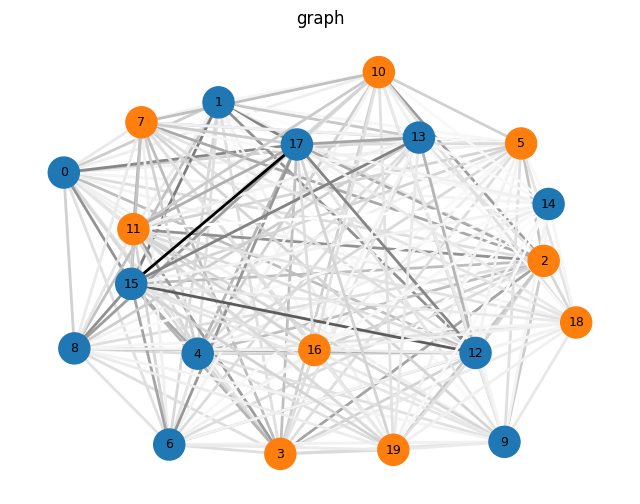

In [5]:
number_communities = 2

community_detection = CommunityDetection(adjacency_matrix=covariance_matrix, number_communities=number_communities)
communities = community_detection.run(solver_type="SIMULATED")

partitions = [set(np.where(communities == c)[0]) for c in np.unique(communities)]

print(f"First community: {list([int(i) for i in partitions[0]])}")
print(f"Second community: {list([int(i) for i in partitions[1]])}")

draw_graph(graph=graph, labels=communities)

Note now we must run the two level asset allocation. We know that asset allocation takes in both `returns` which represents the annual returs for each asset and `covariance_matrix` which is the covarience matrix for all of the assets. This is a bit involved for the upper level since we must combine each community into an affective "asset" and from there calculate what the returns and covariance would be. 

In [6]:
group_average_returns = {} # stores the expected return of each community
group_daily_returns = np.zeros((len(daily_returns), number_communities)) # array: (number of daily_returns, number_communities)

"""
note this converts each community/partition into a single "asset" by computing its average annual return and
its daily return time series then partition_covariance_matrix computes the covariance
"""
for group_index, asset_group in enumerate(partitions):
    asset_group = list(asset_group)

    group_average_returns[group_index] = float(returns.iloc[asset_group].to_numpy().mean())
    group_daily_returns[:, group_index] = daily_returns.iloc[:, asset_group].mean(axis=1).to_numpy()

partition_covariance_matrix = np.cov(group_daily_returns, rowvar=False) # covariance of each partition

Now that we have gotten the effective "returns" and covariance matrix we can run simple asset allocation as follows and get our upper allocations.

In [7]:
upper_allocation = AssetAllocation(returns=list(group_average_returns.values()), covariance=partition_covariance_matrix)
upper_allocations = upper_allocation.run(solver_type="SIMULATED")

print(upper_allocations)

[0. 1.]


Solving for the lower allocations is more trivial, from the returns and covariance matrix above we simply have to get the desired elements of the assets of the community we are running the algorithm over. 

In [8]:
lower_allocations = []

for _, cluster in enumerate(partitions):
    cluster = list(cluster)

    cluster_returns = [returns.iloc[asset].mean().item() for asset in cluster]
    cluster_covariance = covariance_matrix.iloc[cluster, cluster].to_numpy()

    inner_allocation = AssetAllocation(returns=cluster_returns, covariance=cluster_covariance) 
    lower_allocations.append(inner_allocation.run(solver_type="SIMULATED"))

print(lower_allocations)

[array([0.10606061, 0.        , 0.        , 0.01515152, 0.        ,
       0.07575758, 0.06060606, 0.39393939, 0.27272727, 0.        ,
       0.07575758]), array([0.078125, 0.0625  , 0.265625, 0.21875 , 0.      , 0.109375,
       0.015625, 0.25    , 0.      ])]


We have now finished, all that is left is to simply multiply both the `upper_allocations` and `lower_allocations` together.

In [11]:
allocations = np.array([x * y for x, group in zip(upper_allocations, lower_allocations) for y in group])
print(allocations)

[0.       0.       0.       0.       0.       0.       0.       0.
 0.       0.       0.       0.078125 0.0625   0.265625 0.21875  0.
 0.109375 0.015625 0.25     0.      ]
